In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import * 
from tensorflow.keras.preprocessing import image

In [ ]:
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen= image.ImageDataGenerator(rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/train',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
test_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/test',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
validation_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid',
    target_size = (224,224),
    batch_size = 8,
    shuffle=True,
    class_mode = 'categorical')

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 91 images belonging to 4 classes.


In [ ]:
base_model = tf.keras.applications.DenseNet169(weights='imagenet', input_shape=(224,224,3), include_top=False)

for layer in base_model.layers:
    layer.trainable=True
model = Sequential()
model.add(base_model)
model.add(GaussianNoise(0.25))
model.add(GlobalAveragePooling2D())
model.add(Dense(1024,activation='relu'))
model.add(BatchNormalization())
model.add(GaussianNoise(0.25))
model.add(Dropout(0.25))
model.add(Dense(4, activation='sigmoid'))
model.summary()

51877672/51877672 [==============================] - 4s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet169 (Functional)    (None, 7, 7, 1664)        12642880  
                                                                 
 gaussian_noise (GaussianNoi  (None, 7, 7, 1664)       0         
 se)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1664)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              1704960   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                           

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              metrics=['accuracy','AUC','Precision','Recall'])

In [ ]:
from keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',patience=3)
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    steps_per_epoch= 75
    )

Epoch 1/100
75/75 [==============================] - 390s 5s/step - loss: 1.6236 - accuracy: 0.3719 - auc: 0.6230 - precision: 0.3148 - recall: 0.6365 - val_loss: 1.1567 - val_accuracy: 0.4176 - val_auc: 0.7316 - val_precision: 0.3756 - val_recall: 0.8791
Epoch 2/100
75/75 [==============================] - 17s 223ms/step - loss: 1.2082 - accuracy: 0.5461 - auc: 0.7564 - precision: 0.3927 - recall: 0.7755 - val_loss: 1.0885 - val_accuracy: 0.5055 - val_auc: 0.7604 - val_precision: 0.3946 - val_recall: 0.8022
Epoch 3/100
75/75 [==============================] - 14s 184ms/step - loss: 0.9998 - accuracy: 0.5846 - auc: 0.8093 - precision: 0.4182 - recall: 0.8141 - val_loss: 1.0001 - val_accuracy: 0.4945 - val_auc: 0.7973 - val_precision: 0.4041 - val_recall: 0.8571
Epoch 4/100
75/75 [==============================] - 14s 183ms/step - loss: 0.8939 - accuracy: 0.6600 - auc: 0.8351 - precision: 0.4343 - recall: 0.8476 - val_loss: 0.9659 - val_accuracy: 0.5385 - val_auc: 0.8011 - val_precision

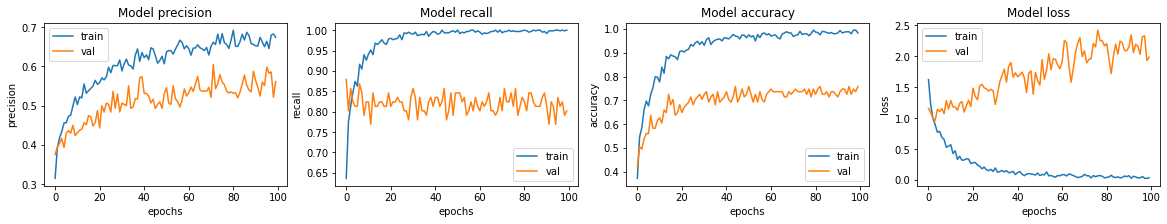

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(20,3))
ax=ax.ravel()
for i,met in enumerate(['precision','recall','accuracy','loss']):
  ax[i].plot(history.history[met])
  ax[i].plot(history.history['val_'+met])
  ax[i].set_title('Model {}'.format(met))
  ax[i].set_xlabel('epochs')
  ax[i].set_ylabel(met)
  ax[i].legend(['train', 'val'])

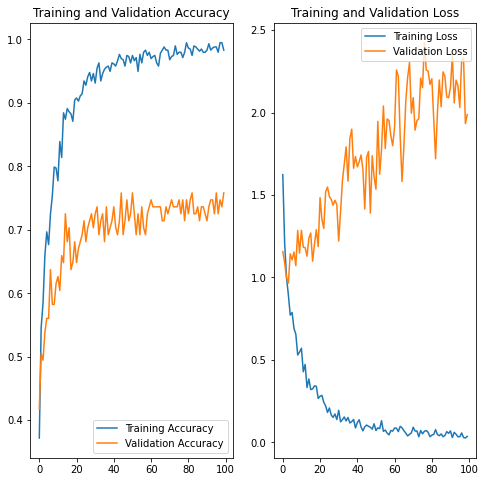

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.evaluate(train_generator)

77/77 [==============================] - 11s 137ms/step - loss: 0.0044 - accuracy: 0.9984 - auc: 0.9997 - precision: 0.8386 - recall: 1.0000


[0.004388206638395786,
 0.9983686804771423,
 0.9997254014015198,
 0.8385772705078125,
 1.0]

In [ ]:
model.evaluate(test_generator)

40/40 [==============================] - 6s 154ms/step - loss: 0.3717 - accuracy: 0.9365 - auc: 0.9764 - precision: 0.6703 - recall: 0.9746


[0.3716888725757599,
 0.9365079402923584,
 0.976423978805542,
 0.6703056693077087,
 0.9746031761169434]

In [ ]:
model.evaluate(validation_generator)

12/12 [==============================] - 2s 135ms/step - loss: 2.3213 - accuracy: 0.7363 - auc: 0.8558 - precision: 0.5414 - recall: 0.7912


[2.3212876319885254,
 0.7362637519836426,
 0.855814516544342,
 0.5413534045219421,
 0.791208803653717]

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/Final Year Project/denseNet169.h5',model)

In [ ]:
mymodel=load_model('/content/drive/MyDrive/Colab Notebooks/Final Year Project/denseNet169.h5')

In [ ]:
mymodel.evaluate(train_generator)

77/77 [==============================] - 11s 138ms/step - loss: 0.0034 - accuracy: 0.9984 - auc: 0.9997 - precision: 0.8444 - recall: 1.0000


[0.0034392038360238075,
 0.9983686804771423,
 0.9997223019599915,
 0.8443526029586792,
 1.0]

In [ ]:
mymodel.evaluate(test_generator)

40/40 [==============================] - 6s 142ms/step - loss: 0.3636 - accuracy: 0.9238 - auc: 0.9752 - precision: 0.6808 - recall: 0.9683


[0.3636150658130646,
 0.9238095283508301,
 0.9752364754676819,
 0.6808035969734192,
 0.9682539701461792]

In [ ]:
mymodel.evaluate(validation_generator)

12/12 [==============================] - 2s 133ms/step - loss: 2.1866 - accuracy: 0.7033 - auc: 0.8718 - precision: 0.5556 - recall: 0.8242


[2.186624526977539,
 0.7032967209815979,
 0.8717948198318481,
 0.5555555820465088,
 0.8241758346557617]

1/1 [==============================] - 0s 33ms/step
[[0.14293109 0.00412542 0.03430203 0.9988348 ]]
THE UPLOADED IMAGE IS SUSPECTED AS: squamous cell carcinoma


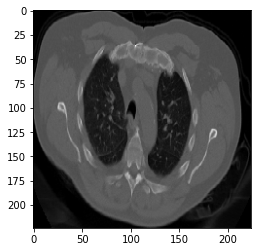

In [ ]:
from keras.preprocessing import image
img = tf.keras.utils.load_img('/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png',target_size=(224,224))
imag = tf.keras.utils.img_to_array(img)
imaga = np.expand_dims(imag,axis=0) 
ypred = model.predict(imaga)
print(ypred)
a=np.argmax(ypred,-1)
if a==0:
  op="Adenocarcinoma"
elif a==1:
  op="large cell carcinoma"
elif a==2:
  op="normal (void of cancer)"
else:
  op="squamous cell carcinoma"    
plt.imshow(img)
print("THE UPLOADED IMAGE IS SUSPECTED AS: "+str(op))  
